<a href="https://colab.research.google.com/github/ssykes-eth/ETH_275-0005-00L/blob/code_exercises/04_langchain_agents_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛰️ WE6 · Notebook 04 — LangChain agents
## *Building a betting desk for a sport nobody has ever played*

> **The story.** It is April 2026 and the Galactic Premier League playoffs start tomorrow.
> You have **1,000 GC** on account at GalacticBets.gg, four rounds of betting, and no idea how
> intergalactic football works. Neither does your agent. The bookmaker is counting on that.
>
> Your job today is not to pick winners. It is to build something that reads a rulebook, reads
> a stat sheet, reads a tabloid, works out which of the three matter — and then spends your
> money.

**How this notebook works**
- Short explanations, then five hands-on tasks marked **🎯** for you to complete.
- Two websites you can actually click around in, a bench for calling the agent's tools by
  hand, and a betting desk for launching the agent itself.
- 🧠 quick checks along the way, and a 🏁 final boss at the end.
- 💰 **All money is Galactic Credits (GC). You start with 1,000 and there are four rounds.**

You have already built an agent loop by hand this morning. This notebook is about what happens
when you stop building loops and start building *agents* — and about the thing that actually
decides whether an agent is any good, which is not the model.

---
## 0. Setup

This notebook is **self-contained**: the first cell pulls the exercise files (the `galactic`
package and the `lc_viz` display helpers) directly from the course repository, which is public
— nothing to sign in to. Run the setup cells below in order.

> 🔑 **You do need an OpenRouter key.** Open the **Secrets** panel (🔑 icon in the left
> sidebar of Colab), add a secret named **`OPENROUTER_API_KEY`** (get one at
> <https://openrouter.ai/keys>), and toggle *Notebook access* on. Cell 0.4 checks it and
> **stops the notebook if it is missing** — better there than sixteen tool calls into a run.

**0.1 — Fetch the exercise files.**

In [1]:
import os, sys

REPO_OWNER = "eth-fdd-fs26"
REPO_NAME  = "FDD-WE6-public"
HELPER     = os.path.join("04_langchain_betting", "exercise", "lc_viz.py")

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

if _in_colab():
    url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
    if not os.path.isdir(REPO_NAME):
        print("Cloning the exercise repo…")
        !git clone -q "$url"
    else:                                 # already cloned earlier — refresh to the latest version
        print("Updating the exercise repo to the latest version…")
        !git -C "$REPO_NAME" pull -q "$url" || echo "  (could not pull — using the existing copy)"

# Move to the REPO ROOT — the folder holding `04_langchain_betting/` — so imports resolve cleanly.
for _root in [REPO_NAME, ".", os.path.dirname(os.getcwd()),
              os.path.dirname(os.path.dirname(os.getcwd())), os.getcwd()]:
    if os.path.exists(os.path.join(_root, HELPER)):
        os.chdir(_root)
        break
else:
    raise FileNotFoundError(
        "Could not find the exercise files (04_langchain_betting/exercise/lc_viz.py). Re-run this "
        "cell; if it still fails, check that the notebook is running on Colab with a network.")
EXERCISE = os.path.join(os.getcwd(), "04_langchain_betting", "exercise")
sys.path.insert(0, EXERCISE)              # make galactic/ and lc_viz importable
print("Working directory:", os.getcwd())

Cloning the exercise repo…
Working directory: /content/FDD-WE6-public


**0.2 — Install dependencies.** Mostly already on Colab; this pins the versions that
matter (LangChain 1.x for `create_agent`, and `langchain-classic` for the 2022 ReAct executor
we compare it against).

In [2]:
%pip install -q -r 04_langchain_betting/exercise/requirements_lc.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are

**0.3 — Import.** The diagrams and quizzes live in **`lc_viz`**, and the whole
Galactic Premier League lives in **`galactic`**, so the teaching cells stay about the idea.
Neither is worth reading — `lc_viz` holds the quiz answers and `galactic` holds the sport.

> ♻️ **Why this cell forgets before it imports.** Cell 0.1 pulls the latest version of the
> exercise, but Python only ever imports a module once per kernel: re-running these cells
> after a pull would keep serving you the code from before it. So we drop the old modules
> first. If you ever change a file yourself, re-run this cell — not just the one you edited.

In [3]:
import importlib, sys

try:                                   # a previous run may still be serving the old code
    import galactic as _stale
    _stale.stop_sites()
except Exception:
    pass

for _m in [m for m in list(sys.modules)
           if m == "lc_viz" or m == "galactic" or m.startswith("galactic.")]:
    del sys.modules[_m]                # forget anything imported before the pull

import lc_viz, galactic

from galactic import Tournament, CURRENCY, STARTING_BANKROLL

print("Environment ready ✅  ·", galactic.LEAGUE_NAME, galactic.SEASON)

Environment ready ✅  · Galactic Premier League 2026


**0.4 — Check the OpenRouter key.** This makes one very small call. If it fails, fix
the secret before going any further — nothing after this point works without it.

In [4]:
from galactic import agents

print(agents.check_api_key())   # raises with instructions if the key is missing or dead

OpenRouter reachable · model google/gemini-3-flash-preview ✅


---
# Part 1 — What a framework is actually for

You built an agent loop by hand this morning: a JSON schema, a `while` loop, a dispatch table,
a step limit, and error handling around the tool call. It worked.

It also had nothing in it that was specific to *your* problem. Every agent ever written has
that same loop. The interesting part — the function that does the thing — was about four lines
of the file.

## 1.1 · The same agent, twice

In [5]:
lc_viz.framework_diagram()

Two things are worth noticing about the right-hand column.

The `@tool` decorator reads the **type hints** to build the JSON schema and the **docstring**
to build the description. That is not a convenience — it means the schema cannot drift away
from the function, because there is only one place to change.

And `create_agent` gives you back an agent you can change your mind about — cap how many
steps it may take, swap the model, have it report progress as it goes — without touching the
loop. That is the trade: you give up control of a loop that was never interesting, and you
get everything already built on top of it.

> ⚠️ **A framework does not make the model smarter.** It is the same model, with the same
> failure modes, on the same day. What changes is how much undifferentiated plumbing you own.

In [6]:
lc_viz.mc_quiz("framework")

## 1.2 · The shelf

The second reason to use a framework is that a great many tools already exist, written and
maintained by people who are not you.

In [7]:
lc_viz.tool_catalogue()

Two of them, live. `DuckDuckGoSearchRun` answers questions about things that happened
after the model's training cutoff; `WikipediaQueryRun` looks things up in a source you can
cite. Neither needs an API key.

> 📖 **Every one of these is documented.** The wrapper below takes two arguments that are
> worth knowing about, and both are in the reference:
> <https://reference.langchain.com/python/langchain-community/utilities/wikipedia/WikipediaAPIWrapper>
> — this is the habit to build, because "which tools exist and what do they take" is the
> question you will actually have on Monday.

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

search = DuckDuckGoSearchRun()
wiki   = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=1,
                                                           doc_content_chars_max=600))

for t in (search, wiki):
    print(f"{t.name:24s} {t.description[:90]}…")

/tmp/ipykernel_1229/1526097465.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun


duckduckgo_search        A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about cur…
wikipedia                A wrapper around Wikipedia. Useful for when you need to answer general questions about peo…


### 🎯 Task 1 — hand the agent its tools

`create_agent` wants two things from you: the tools it may call, and the question to put to
it. Fill in both.

> 💡 **`create_agent(model, tools, system_prompt=...)`** builds the whole loop — schema,
> dispatch, step limit, error handling. You call the result with a list of messages and it
> runs until the model stops asking for tools.
>
> 💡 For the question: you want one that **needs both tools**, so make it two questions in
> one — something settled and citable, and something recent enough that the model cannot be
> sure it knows. A sporting result and a date work nicely.

In [10]:
from langchain.agents import create_agent

llm = agents.build_model()          # OpenRouter, via the key you checked in 0.4

research = create_agent(
    model=llm,
    # 🎯 which of the two tools above should it have?
    tools=[search, wiki],
    system_prompt="You are a research assistant. Use your tools rather than guessing, "
                  "and say which tool told you what.",
)

# 🎯 one question that cannot be answered by one tool alone
out = research.invoke({"messages": [{"role": "user", "content":
    "Who won the last Olympic gold medal in men's 100m sprint and when was the first recorded use of the internet?"}]})
print(out["messages"][-1].content)

According to the search results:

*   **Men's 100m Olympic Gold Medal:** The most recent gold medal was won by **Noah Lyles** of the United States at the 2024 Summer Olympics in Paris. He won the final on August 4, 2024, with a time of 9.79 seconds.
*   **First Recorded Use of the Internet:** While the concept of a "Galactic Network" was described in 1962, the first recorded host-to-host network connection (the precursor to the modern internet) occurred on **October 29, 1969**, between two computers on the ARPANET (one at UCLA and one at SRI). The first "true" internet, involving the interchange of different networks using TCP/IP protocols, was realized in **1981** when ARPANET connected to CSNET.


Read the answer and check it actually used both — the system prompt asked it to say
which tool told it what.

You wrote none of the machinery. No search API wrapper, no rate limiting, no HTML parsing, no
Wikipedia client — and no agent loop.

## 1.3 · Your agent speaks text. Your code does not.

Everything so far came off a shelf. The thing you actually want an agent to use at work is
usually not on any shelf: it is a service somebody in your company wrote years ago, it is
ordinary Python, and it has never heard of a language model.

The exercise ships one of those. `galactic.desk` is the scouting desk — a normal module with
normal functions. Ask it for a report on a club.

In [11]:
from galactic import desk

report = desk.scouting_report("Quasar Queens")
print(report)              # ← this is what your agent would receive

That is not the desk being unhelpful. That is what a Python object looks like when
something asks for it as text, and **text is the only thing an agent ever receives**. Note that
*you* cannot read that line either — the problem is not that the model is stupid.

The attributes are all there, of course. It is the writing-them-down that fails.

In [12]:
import json

print(vars(report), "\n")

try:
    print(json.dumps(vars(report)))       # the desk stores ratings as objects, not numbers
except TypeError as exc:
    print("TypeError:", exc)

{'club': 'Quasar Queens', 'verdict': "Camp is openly split. Watching two full matches, one thing stands out: their first touch under pressure is the best thing about them. A scout's opinion, not a League statistic.", 'ratings': {'confidence': <galactic.desk.Rating object at 0x7bc31a1646b0>, 'coherence': <galactic.desk.Rating object at 0x7bc308d66ea0>, 'scout_certainty': <galactic.desk.Rating object at 0x7bc3010bd550>}} 

TypeError: Object of type Rating is not JSON serializable


`json.dumps` takes a `default=` argument for exactly this: a function it calls for
anything it does not know how to write down. The laziest possible one is `str`.

In [13]:
print(json.dumps(vars(report), default=str))

{"club": "Quasar Queens", "verdict": "Camp is openly split. Watching two full matches, one thing stands out: their first touch under pressure is the best thing about them. A scout's opinion, not a League statistic.", "ratings": {"confidence": "<galactic.desk.Rating object at 0x7bc31a1646b0>", "coherence": "<galactic.desk.Rating object at 0x7bc308d66ea0>", "scout_certainty": "<galactic.desk.Rating object at 0x7bc3010bd550>"}}


Half a fix — the addresses are back, one level down. But you can see the shape of the
job: a few lines and the desk's objects come out as text an agent can read. Call that
**direction one — objects → text**.

Now the other direction, which is the one people do not see coming. You want the agent to
actually *place* a bet, and the desk has a function for it.

In [14]:
import inspect

print("desk.place_bets", inspect.signature(desk.place_bets))

desk.place_bets (selections: 'list[str]', stake_each: 'float') -> 'str'


And here is your agent, doing its best:

> *"I'd put 300 credits across the Quasar Queens and the Nebula Nomads."*

`place_bets` will not take that sentence. It wants a **list of strings** and **one float**, and
no amount of prompting turns English into those. What a model *can* do reliably is emit
**JSON in a shape you published in advance** — so you publish a shape, and something turns
that JSON into the arguments the desk already accepts. **Direction two — JSON → objects**.

Two translations, sitting between an agent that speaks text and a program that speaks objects.
That layer is not optional; you were going to write it either way.

In [15]:
lc_viz.mcp_diagram()

### 🎯 Task 2 — write the layer, both directions

This cell **writes a file**: a real MCP server, a separate program that imports the desk and
exposes two of its functions. Everything is there except the two translations. Fill them in and
run the cell — `%%writefile` saves it to disk, it does not execute anything.

> 💡 **Outbound.** `json.dumps(..., default=to_wire)` calls `to_wire` for every value it cannot
> serialise, and a `Rating` is one of those. It holds `.value` and `.out_of`. The gap is inside
> an f-string, so anything in `{curly braces}` is evaluated and dropped into the text —
> `f"{obj.value}"` writes the number. The agent gets one look at this and no follow-up
> question: a bare `82` means nothing when the next rating is out of 5.
>
> 💡 **Inbound.** `BetSlip` is a **pydantic model, and a pydantic model is a JSON shape** —
> each field becomes one JSON key, its type hint becomes the JSON type (`list[str]` → an array
> of strings), and its `Field(description=...)` becomes the line the model reads about that
> key. The SDK publishes that shape, checks what the model sends against it, and hands you a
> ready-made `BetSlip` object: `slip.picks` and `slip.total_stake` are already there. The desk
> wants a list and a **per-bet** number — and one of those two is not what the slip carries.

In [16]:
%%writefile 04_langchain_betting/exercise/mcp_servers/betting_desk_server.py
"""BettingDesk — the translation layer between an agent (text) and the desk (objects).

A separate program. It imports ``galactic.desk``, which is ordinary Python, and exposes two of
its functions over MCP. Run it by hand and it just sits there waiting for frames on stdin:

    python mcp_servers/betting_desk_server.py
"""

from __future__ import annotations

import json
import os
import sys

from mcp.server.fastmcp import FastMCP
from pydantic import BaseModel, Field

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
from galactic import desk                                              # noqa: E402

mcp = FastMCP("betting_desk")


# ============================================================ outbound: objects -> text
def to_wire(obj):
    """Called by ``json.dumps`` for anything it does not know how to write down."""
    if isinstance(obj, desk.Rating):
        return f"{obj.value}/{obj.out_of}"     # 🎯 fill in between the quotes. Anything in {curly braces} is
                          #    evaluated: f"{obj.value}" writes the number. What else does
                          #    the agent need in order to know what that number means?
    return str(obj)


@mcp.tool()
def scouting_report(club: str) -> str:
    """A scout's verdict on a club, with the desk's three confidence ratings.

    Args:
        club: the club's name, e.g. 'Quasar Queens'.
    """
    report = desk.scouting_report(club)                # a ScoutingReport object
    return json.dumps(vars(report), default=to_wire)   # ... and here it is as text


# ============================================================ inbound: JSON -> objects
class BetSlip(BaseModel):
    """The only shape the agent is allowed to speak in. The MCP SDK publishes this as a JSON
    schema and hands us back a validated ``BetSlip``."""

    picks: list[str] = Field(description="Clubs to back, one per bet.")
    total_stake: float = Field(description="Total to stake, split evenly across the picks.")


@mcp.tool()
def place_bets(slip: BetSlip) -> str:
    """Place one bet per pick, splitting the total stake evenly between them.

    Args:
        slip: the bet slip: which clubs to back and how much to stake in total.
    """
    stake_each = slip.total_stake / len(slip.picks)
    return desk.place_bets(slip.picks, stake_each)   # 🎯 the desk wants a list, then a per-bet amount


if __name__ == "__main__":
    mcp.run(transport="stdio")

Writing 04_langchain_betting/exercise/mcp_servers/betting_desk_server.py


Now start it and connect. One line, and what comes back are ordinary LangChain tools —
built from the type hints and docstrings in the file you just wrote.

In [17]:
desk_tools = {t.name: t for t in await galactic.connect_mcp("betting_desk")}
print(list(desk_tools))

# the shape the model is allowed to speak in — published from your BetSlip, not written by you
print(json.dumps(desk_tools["place_bets"].args_schema, indent=1)[:400], "…")

['scouting_report', 'place_bets']
{
 "$defs": {
  "BetSlip": {
   "description": "The only shape the agent is allowed to speak in. The MCP SDK publishes this as a JSON\nschema and hands us back a validated ``BetSlip``.",
   "properties": {
    "picks": {
     "description": "Clubs to back, one per bet.",
     "items": {
      "type": "string"
     },
     "title": "Picks",
     "type": "array"
    },
    "total_stake": {
     "des …


In [18]:
report_tool = desk_tools["scouting_report"]
out = galactic.mcp_text(await report_tool.ainvoke({"club": "Quasar Queens"}))
print(out, "\n")
assert "100" in out, "a rating that arrives without its scale leaves the agent guessing"

slip = {"picks": ["Quasar Queens", "Nebula Nomads"], "total_stake": 300}
placed = galactic.mcp_text(await desk_tools["place_bets"].ainvoke({"slip": slip}))
print(placed)
assert "150.00" in placed, "300 across two picks is 150 each — check what you divided"

print("\nBoth directions, and the desk never learned what a model is ✅")

{"club": "Quasar Queens", "verdict": "Camp is openly split. Watching two full matches, one thing stands out: their first touch under pressure is the best thing about them. A scout's opinion, not a League statistic.", "ratings": {"confidence": "77/100", "coherence": "84/100", "scout_certainty": "4/5"}} 

Accepted 2 bet(s) at 150.00 GC each (300.00 GC total): Quasar Queens, Nebula Nomads.

Both directions, and the desk never learned what a model is ✅


So that is an MCP server: a JSON shape going in, readable text coming out, and a tiny bit of
glue in between. Which means you can now read anybody's — including the one this exercise
ships as *someone else's*, called ScoutBot. Same one line to connect.

In [19]:
mcp_tools = await galactic.connect_mcp()          # scoutbot, a server we did not write

for t in mcp_tools:
    print(f"{t.name:22s} {t.description.splitlines()[0]}")

scouting_report        A scout's one-paragraph verdict on a club, in the scout's own florid style.
travel_conditions      Transit conditions between two orbitals, which affect nothing but are asked about a lot.


Those drop straight in next to the two we imported off the shelf. Same agent, same
`create_agent` call — it neither knows nor cares that half its toolbox is coming out of
somebody else's process.

In [20]:
scout = create_agent(
    model=llm,
    tools=[wiki] + mcp_tools,
    system_prompt="You are a scout's assistant. Use the tools available to you.",
)

out = await scout.ainvoke({"messages": [{"role": "user", "content":
    "Give me the scouting report on the Quasar Queens, and tell me how long the trip is "
    "from Orbital Kesh."}]})
print(out["messages"][-1].content)

The scouting report for the **Quasar Queens** notes that the camp is currently openly split. However, their performance on the pitch shows a significant strength: their first touch under pressure is considered the best aspect of their game.

Regarding the journey from **Orbital Kesh**, the trip to the playoff venue (Neutral Orbital 7) takes approximately **42 hours**. Gravity differentials are within tolerance, and due to league normalization protocols, the travel time will have no effect on player output.


> 🔭 **Why this matters more than it looks.** Stripe, Sentry, Linear, GitHub, Figma and
> a long list of others now publish MCP servers themselves — the same two directions you just
> wrote, written by the people who own the system. You are no longer writing a wrapper per
> vendor per framework; you are connecting to one they maintain. That is a different kind of
> ecosystem from "someone contributed a tool class in 2023".

In [21]:
lc_viz.mc_quiz("mcp")

## 1.4 · Harnesses — the part people forget to vary

You now have a model and tools. The third ingredient has no good name; we will call it the
**harness**. It is the loop: how the model is asked to choose a tool, how its choice is turned
into a call, and how the result comes back.

Three of them, and you will be switching between them by hand later on.

In [22]:
lc_viz.harness_diagram()

> ⚠️ **The middle column is not just "newer".** Under classic ReAct the model *writes
> out* its arguments as prose and something has to parse them back. With one string argument
> that is fine. With three, it is where your evening goes.

In [23]:
lc_viz.true_false_quiz("agents")

### 🎯 Task 3 — the same two directions, for free

In Task 2 you published a JSON shape by hand and wrote the conversion into your function's
arguments. Inside your own process you have to do none of that: `@tool` reads the **type hints**
and writes the schema, and reads the **docstring** and writes the description the model sees.

So this time the signature and the docstring are already there — **read them first**, because
between them they are the entire input to what the next cell prints. All that is left for you
is the body: the same arithmetic you sent the desk in Task 2, a total stake split evenly
between the picks on a slip.

> 💡 Look at what `picks: list[str]` turns into. That is the same array-of-strings you typed
> out by hand as a `BetSlip` field, generated here from a hint you would have written anyway —
> and nothing else in the cell mentions JSON at all.

In [24]:
from langchain_core.tools import tool

@tool
def stake_per_pick(total_stake: float, picks: list[str]) -> float:
    """Work out what goes on each pick when a total stake is split evenly between them.

    Give it the total you want to stake and the clubs you want to back; it returns the
    amount to put on one bet.
    """
    return total_stake / len(picks)                     # 🎯 300 across two picks is 150 each

# --- self-check
print(stake_per_pick.name)
print(stake_per_pick.description)
print(stake_per_pick.args_schema.model_json_schema()["properties"])

assert stake_per_pick.invoke({"total_stake": 300, "picks": ["Quasar Queens", "Galaxy Giants"]}) == 150
assert stake_per_pick.invoke({"total_stake": 90, "picks": ["Nebula Nomads"]}) == 90
props = stake_per_pick.args_schema.model_json_schema()["properties"]
assert props["total_stake"]["type"] == "number", "the schema is built from your type hints"
assert props["picks"]["type"] == "array" and props["picks"]["items"]["type"] == "string", \
    "a list of club names — and the schema says so without you writing any of it"
assert len(stake_per_pick.description) > 20, "the description IS your docstring"
print("\nA JSON schema you did not write, from a function you did ✅")

stake_per_pick
Work out what goes on each pick when a total stake is split evenly between them.

    Give it the total you want to stake and the clubs you want to back; it returns the
    amount to put on one bet.
{'total_stake': {'title': 'Total Stake', 'type': 'number'}, 'picks': {'items': {'type': 'string'}, 'title': 'Picks', 'type': 'array'}}

A JSON schema you did not write, from a function you did ✅


---
# Part 2 — The Galactic Premier League

Eight clubs. A regular season everyone has already played. A double-elimination playoff
starting tomorrow, and a bookmaker willing to take your money on all fourteen matches of it.

You have **1,000 GC** and four rounds of betting. Between rounds, results are settled and your
balance moves. **Once a round is settled you cannot bet into it again** — which is the only
honest way to run this, and worth saying out loud before you start.

## 2.1 · Two websites, and the toolbox that reads them

Everything the League publishes lives on two sites, and both of them run inside this notebook.

**GalacticBets.gg** is the bookmaker: the bracket, the prices, the league table, the squads,
the closed-doors scrim block, and your bet slip.

In [25]:
t = Tournament()             # your bankroll, your bracket, your four rounds
print(t, "\n(a snapshot, printed once — the site below is the live view)")
galactic.open_betting(t);    # GalacticBets.gg, embedded below

<Tournament round=1/4 wallet=1000GC open_markets=5 bets=0> 
(a snapshot, printed once — the site below is the live view)


<IPython.core.display.Javascript object>

> ⚠️ **Run that cell once.** `Tournament()` builds a *new* tournament, so re-running it
> later throws away the round you are in, the bets you placed and the balance you have, and
> starts again at round 1 with 1,000 GC. If you ever want a clean slate that is exactly how
> you get one — and if you did it by accident, the desk in §2.2 and the sites will simply
> follow the newest tournament together.

**StarScoop** is the tabloid. Roughly a third of what is on its front page moves a
price and the rest is hairstyles, and nothing on it is labelled which. It also *covers the
playoffs*: settle a round and the results are on its front page a moment later, which is how
your agent finds out that a round has been played at all.

In [26]:
galactic.open_news(t);       # StarScoop, embedded below

<IPython.core.display.Javascript object>

> 🔄 **Both sites are live.** They are two little web servers reading the same
> tournament you are betting into, and they poll it — settle a round and the bracket redraws
> itself, the prices change, the standings grow a **Playoffs** column and StarScoop publishes
> the report. You do not have to refresh anything; just scroll back up and look.

### 🎯 Task 4 — five minutes on the sites, five on the toolbox

> 💰 **The one bit of jargon you need.** Every selection has a **price** — a number like
> `2.50`. It is a multiplier: stake 100 GC at `2.50` and you get 250 GC back if it wins,
> nothing if it loses. So a **short** price (say `1.20`) means the bookmaker thinks it is
> very likely and will pay you almost nothing for it; a **long** price (`8.00`) means the
> opposite. That is the whole of it — no arithmetic required today.

**First, click around** the **Bracket**, **Matches**, **Standings**, **Teams**, **Scrims**
and **Rules** tabs, and answer these for yourself:

1. Which four matches can you bet on **right now**? What can you *not* bet on yet, and why?
2. Andromeda Asteroids finished top of the table. Find their price to win the whole
   tournament — is anybody priced **shorter**, i.e. does the bookmaker fancy anyone more?
3. Open **Teams** and look at any squad. There are nine statistical columns. Which of them
   would you use to compare two clubs — and how would you know? **Open the Rules tab and read
   §3 and §4 before you answer**; intergalactic football is not football, and those two
   sections decide which columns can possibly bear on a result.
4. On **Scrims**, each match has a score *and* a possession-retention figure. Find a match
   where those two disagree.

> ⚠️ **Do not skip question 3.** Everything in the rest of this notebook turns on it.

**Then open the bench below.** Your agent cannot click a website; it reaches all of this
through six tools, and each tool has two to five **sub-skills**. The bench lets you call any of
them by hand and see exactly what comes back — which is the only way to make an informed
decision later about which ones to switch off.

Work through the six prompts along the top of the bench, and as you go, keep an eye on the
right-hand pane: that text is the *entire* description the model gets for a tool. It is the
whole reason the model would ever pick one tool over another.

> 🔭 **Try `research_team → playoffs` first.** In round 1 it is honestly empty, and that is
> worth seeing: it is the tool that tells an agent in round 2 which matches have already been
> played, how they finished and who is out. An agent without it — or without `read_news` —
> bets round 2 as though the tournament had not started.

> 🧹 **Six prompts, six tools — but only five tools answer anything.** One of them answers
> none of the six questions, and it is not hiding: read the descriptions and you can rule it
> out without running anything. Work out **which**, and then the harder question — what does
> leaving it switched on cost you, given that the agent has to read its description on every
> single turn whether it calls it or not?
> Deciding a tool is useless is half of tool design; the other half is noticing that something
> nobody has wrapped yet *should* be a tool.

In [27]:
galactic.tool_explorer(t);   # the trailing ; keeps the notebook from drawing it twice

HTML(value='<style>\n.explore-1 {background:#ffffff;border:1px solid #e6e8ee;border-radius:14px;padding:18px;\…

## 2.2 · The betting desk

Everything now goes into one panel, with a bookmark for each thing you can change — and those
four things are, between them, what decides what any agent does:

| bookmark | what it changes |
|---|---|
| 📝 **Prompt** | what the agent is asked for. Also the model, the temperature and the step limit. |
| 🧰 **Tools** | which tools it gets, and **which sub-skills within each tool**. Untick `player_stats → Discipline` and the words "prolonged touch" vanish from the agent's entire context. |
| ⚙️ **Harness** | the three loops from §1.4. |
| ▶️ **Run** | run it against your real wallet, then settle the round. |
| 🎲 **Variability** | the same setup three times over, in sandbox copies. |

**Reading a run.** The strip above the transcript lights up as the agent moves through the
stages — *reads the rules → researches the clubs → checks the prices → stakes the money →
explains itself* — with the running total of what it has staked on the right. An agent that
lights "stakes the money" before "reads the rules" is telling you something, and you will see
it without reading a word of the transcript.

**Reading the rail.** Along the top: your balance, and one stop per round. A settled round is
drawn **🔒 locked**, with what your bets did in it. That is not decoration — `⏭ Settle` asks
twice and then closes the round permanently. Once you know who won round 1, betting on round
1 is over. You have four rounds and the balance you finish with is the balance you finish
with.

> 🕹️ **Suggested first experiment.** Run *Value hunter* on the tool-calling harness with
> everything switched on. Then run *Favourite-backer* with everything off except `betting`.
> Then decide which of the two you would rather have managing money.

In [28]:
galactic.control_panel(t);

HTML(value='<style>\n.desk-2 {background:#ffffff;border:1px solid #e6e8ee;border-radius:14px;padding:18px;\n  …

### 🎯 Task 5 — four experiments, one variable each

Change **one thing at a time**, and keep the round open until you have finished all four.

1. **Harness.** Same prompt, same tools; run classic ReAct, then tool calling. Compare the
   step counts and the stage strips. Where did ReAct waste turns?
2. **A whole tool.** Run once with `galactic_almanac` on, then untick it and run again. Did the
   agent call it? If it did, how many steps went into mascots — and if it did not, what did it
   still have to read before deciding not to?
3. **A sub-skill.** Untick `player_stats → Discipline`, or `read_news` entirely, and rerun.
   Read the trace, not just the bets: what does the agent no longer even consider?
   After you have settled round 1, try that with `research_team → Playoffs so far` and
   `read_news` both off — the agent is now betting round 2 with no idea round 1 happened.
4. **Variance.** Pick your best setup and open 🎲 **Variability**. How far apart are the three
   bankrolls? Do the three runs even agree on which selections to back?

Then settle the round and go again.

In [29]:
lc_viz.mc_quiz("subskills")   # you have just done this one by hand — what did it change?

---
## 2.3 · What was actually worth knowing

Before the chart, the answer to question 3 of Task 4 — the one about which of the nine
statistical columns are worth reading.

> 📕 **It is all in the rulebook.** §4 equalises four of the nine before kick-off: they are
> published because member worlds ask for them, not because they decide anything. Meanwhile §3
> and §5 make two columns matter far more than they look — the ones about keeping the ball and
> about giving it away.
>
> That is the whole game, and the bookmaker knows it perfectly well. What a bookmaker prices is
> what the *crowd* believes, and the crowd likes a big strong side. Your agent reaches the same
> laws through `read_rules`, which is the tool it should be reaching for first.

While you were betting, we ran the same tournament 150 times with different policies — each
seeing only what your agent's tools expose. Here is what each piece of information was worth.

In [30]:
lc_viz.signal_ladder()

Three things to take away from that chart.

**The rulebook flips the sign.** Everything above the line is losing money; the first policy
that reads §3 and §4 is the first one that makes any. Not because it is cleverer, but because
it stops using two columns that were never predictive.

**The two most intuitive shortcuts are the two worst.** Backing the bigger, stronger side and
backing the higher league finish both lose more than simply backing the favourite. Plausible
information that is wrong is worse than no information, because you stake more on it.

**And the last column is the uncomfortable one.** Even the best policy on that board loses
money in more than a third of tournaments. Fourteen matches is a tiny sample for a 17% edge.

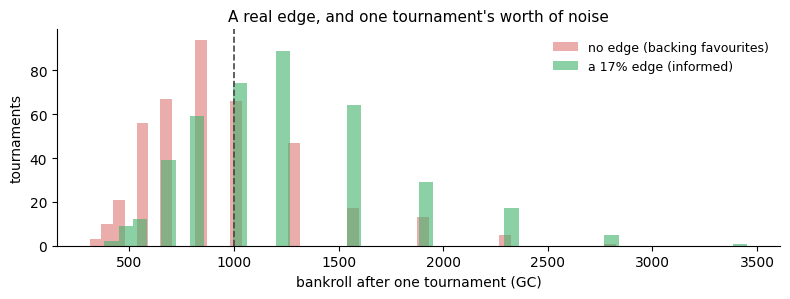

The green distribution is genuinely better. It also overlaps the red one almost completely.
That overlap is why you cannot judge a prompt from a single run.


In [31]:
lc_viz.edge_vs_variance()

> ⚓ **The anchor idea.** You cannot tell a good agent from a lucky one in a single run.
> Everything you will be asked to judge in production — a prompt change, a new tool, a
> different model — sits inside a distribution that looks like that green one, and a single
> A/B of one run each tells you almost nothing. This is not a betting problem. It is the
> evaluation problem, and it is the same shape everywhere.

## 2.4 · The whole point

Forget the sport. Four things transfer to whatever you actually build.

In [32]:
lc_viz.the_whole_point()

## 2.5 · Wrap-up

| The idea | Where you met it | In one line |
|---|---|---|
| A framework removes plumbing, not judgement | §1.1 | Same model, less of your code |
| The community shelf | §1.2, Task 1 | Hundreds of tools you did not write |
| An agent reads text; your code speaks objects | §1.3 | Something has to translate, both ways |
| MCP is that translation, in a shape others can use | §1.3, Task 2 | JSON in, readable text out |
| `@tool` builds the schema from your signature | §1.4, Task 3 | Type hints and docstring, nothing else |
| Structured tool calls beat parsed text | §1.4 | No regex between the model and your function |
| The harness | §1.4, Task 5 | The loop, and it changes more than you expect |
| A tool's description is prompt | §2.1, Task 5 | Remove a sub-skill and the idea disappears |
| A useless tool is not free | §2.1, Task 5 | You pay for it on every turn, called or not |
| Signal needs a model of the world | §2.1, §2.3 | The rulebook is what makes the stat sheet readable |
| One run proves nothing | §2.3, Task 5 | Judge distributions, not anecdotes |

> 🔭 **Where this goes next.** You changed four things by hand and eyeballed the traces. The
> next step is doing that automatically and at scale — which is evaluation, and which is what
> the rest of the weekend is about.

---
## 🏁 Final boss — clear the notebook

Everything you just learned, one statement at a time: **the sport, the prices, the tools, the
harnesses.** The rules: **3 lives**, **10 seconds** per question, and a wrong answer *or* a
timeout costs a life. Reach **12 correct** to pass. Good luck. 🍀

In [33]:
lc_viz.flash_quiz()

**Cleanup.** Shuts down the two web servers. Run it when you are done.

In [34]:
galactic.stop_sites()
print("Servers stopped. Final balance:", t.wallet, CURRENCY,
      "· champion:", t.champion or "not yet decided")

Servers stopped. Final balance: 1000.0 GC · champion: not yet decided
